# Sesión 2 — GridSearch, RandomizedSearch y Optuna

**Caso:** selección reproducible para Gradient Boosting en InmoValor.

**Pregunta problema:** ¿cómo elegir hiperparámetros bajo un presupuesto explícito sin convertir test en parte del ajuste?

## Objetivos y contrato

Los tres métodos usarán MAE, los mismos tres folds y 16 configuraciones. Test permanecerá cerrado hasta elegir un procedimiento. Comparar presupuestos iguales no convierte los métodos en idénticos: Grid recorre puntos fijos, Random muestrea distribuciones y Optuna adapta sus propuestas.

In [1]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)

def locate_dataset():
    candidates = [
        Path("datasets/public/Ames_Housing.csv"),
        Path("../../datasets/public/Ames_Housing.csv"),
        Path("../datasets/public/Ames_Housing.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("No se encontró datasets/public/Ames_Housing.csv")

data_path = locate_dataset()
frame = pd.read_csv(data_path)
X = frame.drop(columns=["SalePrice", "Id"])
y = frame["SalePrice"].astype(float)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

def make_preprocessor(data):
    numeric = data.select_dtypes(include=np.number).columns.tolist()
    categorical = data.select_dtypes(exclude=np.number).columns.tolist()
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        # "Missing" conserva la semántica de amenidades ausentes y evita
        # eliminar columnas que estén completamente vacías dentro de un fold.
        ("imputer", SimpleImputer(
            strategy="constant", fill_value="Missing", keep_empty_features=True
        )),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, numeric),
        ("categorical", categorical_pipe, categorical),
    ])

def wrap(model, data=X_dev):
    return Pipeline([
        ("preprocess", make_preprocessor(data)),
        ("model", model),
    ])

print(f"Datos: {frame.shape[0]:,} viviendas, {X.shape[1]} predictores")
print(f"Desarrollo: {len(X_dev):,} | Test reservado: {len(X_test):,}")


from scipy.stats import randint, loguniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
warnings.filterwarnings("ignore", message="IProgress not found.*")
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

Datos: 1,460 viviendas, 79 predictores
Desarrollo: 1,168 | Test reservado: 292


## 1. Pipeline y espacio conceptual

Ajustaremos `n_estimators`, `learning_rate`, `max_depth` y `min_samples_leaf`. El número de árboles y la tasa de aprendizaje interactúan; profundidad y tamaño de hoja controlan complejidad local.

In [2]:
estimator = wrap(GradientBoostingRegressor(random_state=RANDOM_STATE))
grid_space = {
    "model__n_estimators": [100, 250],
    "model__learning_rate": [0.03, 0.10],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [5, 20],
}
grid_candidates = int(np.prod([len(values) for values in grid_space.values()]))
print("Configuraciones de Grid:", grid_candidates)

Configuraciones de Grid: 16


## 2. GridSearchCV

La cuadrícula evalúa el producto cartesiano completo. `best_score_` usa la convención negativa de scikit-learn; lo transformamos nuevamente a MAE.

In [3]:
grid_search = GridSearchCV(
    estimator, grid_space, scoring="neg_mean_absolute_error",
    cv=CV, n_jobs=1, refit=True, return_train_score=False,
)
started = time.perf_counter()
grid_search.fit(X_dev, y_dev)
grid_seconds = time.perf_counter() - started
print("Mejor MAE CV:", -grid_search.best_score_)
print("Mejores parámetros:", grid_search.best_params_)

Mejor MAE CV: 16330.610365575063
Mejores parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 20, 'model__n_estimators': 250}


In [4]:
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_view = grid_results[[
    "rank_test_score", "mean_test_score", "std_test_score", "mean_fit_time", "params"
]].copy()
grid_view["MAE_CV"] = -grid_view.pop("mean_test_score")
grid_view.sort_values("rank_test_score").head(8)

,rank_test_score,std_test_score,mean_fit_time,params,MAE_CV
15,1,927.480,1.262,"{'model__learning_rate': 0.1, 'model__max_dept...","16,330.610"
13,2,"1,123.585",1.308,"{'model__learning_rate': 0.1, 'model__max_dept...","16,422.341"
11,3,"1,059.747",0.939,"{'model__learning_rate': 0.1, 'model__max_dept...","16,504.820"
9,4,"1,441.652",0.962,"{'model__learning_rate': 0.1, 'model__max_dept...","16,661.620"
14,5,"1,103.900",0.525,"{'model__learning_rate': 0.1, 'model__max_dept...","16,896.035"
7,6,"1,275.861",1.279,"{'model__learning_rate': 0.03, 'model__max_dep...","16,908.945"
5,7,"1,340.145",1.327,"{'model__learning_rate': 0.03, 'model__max_dep...","16,944.914"
12,8,"1,208.672",0.545,"{'model__learning_rate': 0.1, 'model__max_dept...","17,057.188"


## 3. RandomizedSearchCV

Conservamos 16 candidatos, pero permitimos más valores dentro de rangos comparables. `learning_rate` se muestrea en escala logarítmica.

In [5]:
random_space = {
    "model__n_estimators": randint(100, 251),
    "model__learning_rate": loguniform(0.03, 0.10),
    "model__max_depth": randint(2, 4),
    "model__min_samples_leaf": randint(5, 21),
}
random_search = RandomizedSearchCV(
    estimator, random_space, n_iter=16,
    scoring="neg_mean_absolute_error", cv=CV,
    random_state=RANDOM_STATE, n_jobs=1, refit=True,
    return_train_score=False,
)
started = time.perf_counter()
random_search.fit(X_dev, y_dev)
random_seconds = time.perf_counter() - started
print("Mejor MAE CV:", -random_search.best_score_)
print("Mejores parámetros:", random_search.best_params_)

Mejor MAE CV: 16362.278471230515
Mejores parámetros: {'model__learning_rate': np.float64(0.047544742632230484), 'model__max_depth': 3, 'model__min_samples_leaf': 20, 'model__n_estimators': 230}


In [6]:
random_results = pd.DataFrame(random_search.cv_results_)
random_results[["rank_test_score", "mean_test_score", "std_test_score",
                "mean_fit_time", "params"]].sort_values("rank_test_score").head(8)

,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
9,1,"-16,362.278","1,141.129",1.194,"{'model__learning_rate': 0.047544742632230484,..."
12,2,"-16,514.309","1,265.166",1.010,"{'model__learning_rate': 0.05910887468098256, ..."
3,3,"-16,547.521","1,251.658",1.180,"{'model__learning_rate': 0.04483430011492309, ..."
1,4,"-16,878.997","1,285.300",0.822,"{'model__learning_rate': 0.07670172066070004, ..."
10,5,"-16,922.423","1,255.211",0.652,"{'model__learning_rate': 0.08448231687513277, ..."
14,6,"-16,930.755","1,177.153",0.597,"{'model__learning_rate': 0.06829442079674036, ..."
6,7,"-17,046.991","1,408.648",0.772,"{'model__learning_rate': 0.05642937488667569, ..."
13,8,"-17,155.557","1,047.345",1.102,"{'model__learning_rate': 0.033743639849862894,..."


## 4. Optuna con TPE

La función objetivo recibe un `trial`, propone hiperparámetros, ejecuta la misma CV y devuelve MAE. El estudio permanece en memoria y usa semilla fija. No aplicamos pruning porque cada evaluación es una CV corta y completa.

In [7]:
def objective(trial):
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 250),
        "model__learning_rate": trial.suggest_float(
            "learning_rate", 0.03, 0.10, log=True
        ),
        "model__max_depth": trial.suggest_int("max_depth", 2, 3),
        "model__min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 20),
    }
    candidate = clone(estimator).set_params(**params)
    scores = -cross_val_score(
        candidate, X_dev, y_dev,
        scoring="neg_mean_absolute_error", cv=CV, n_jobs=1,
    )
    trial.set_user_attr("fold_sd", float(scores.std(ddof=1)))
    return float(scores.mean())

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="minimize", sampler=sampler)
started = time.perf_counter()
study.optimize(objective, n_trials=16, n_jobs=1)
optuna_seconds = time.perf_counter() - started
print("Mejor MAE CV:", study.best_value)
print("Mejores parámetros:", study.best_params)

Mejor MAE CV: 16402.60693851182
Mejores parámetros: {'n_estimators': 216, 'learning_rate': 0.06575066036677875, 'max_depth': 3, 'min_samples_leaf': 17}


In [8]:
optuna_results = study.trials_dataframe()
optuna_results[["number", "value", "duration",
                "params_learning_rate", "params_max_depth",
                "params_min_samples_leaf", "params_n_estimators",
                "user_attrs_fold_sd"]].sort_values("value").head(8)

,number,value,duration,params_learning_rate,params_max_depth,params_min_samples_leaf,params_n_estimators,user_attrs_fold_sd
14,14,"16,402.607",0 days 00:00:03.390465,0.066,3,17,216,"1,174.620"
13,13,"16,455.772",0 days 00:00:03.534406,0.053,3,16,221,"1,251.533"
15,15,"16,488.027",0 days 00:00:03.379491,0.064,3,18,214,"1,289.327"
12,12,"16,522.878",0 days 00:00:03.478052,0.099,3,15,218,990.877
11,11,"16,551.030",0 days 00:00:03.919440,0.053,3,15,244,"1,361.916"
0,0,"16,627.937",0 days 00:00:02.539451,0.094,3,14,156,"1,061.534"
10,10,"16,691.002",0 days 00:00:03.945147,0.048,3,15,243,"1,363.410"
8,8,"16,842.376",0 days 00:00:01.826993,0.094,3,17,109,"1,318.486"


## 5. Comparación con presupuesto común

El tiempo depende del paralelismo y del equipo; por ello es evidencia operativa, no una propiedad universal. La desviación del mejor candidato ayuda a evitar conclusiones por diferencias minúsculas.

In [9]:
grid_best_index = grid_search.best_index_
random_best_index = random_search.best_index_
search_summary = pd.DataFrame([
    {"método": "GridSearchCV", "candidatos": len(grid_results),
     "mejor_MAE_CV": -grid_search.best_score_,
     "sd_folds": grid_results.loc[grid_best_index, "std_test_score"],
     "segundos": grid_seconds},
    {"método": "RandomizedSearchCV", "candidatos": len(random_results),
     "mejor_MAE_CV": -random_search.best_score_,
     "sd_folds": random_results.loc[random_best_index, "std_test_score"],
     "segundos": random_seconds},
    {"método": "Optuna TPE", "candidatos": len(study.trials),
     "mejor_MAE_CV": study.best_value,
     "sd_folds": study.best_trial.user_attrs["fold_sd"],
     "segundos": optuna_seconds},
]).sort_values("mejor_MAE_CV")
search_summary

,método,candidatos,mejor_MAE_CV,sd_folds,segundos
0,GridSearchCV,16,"16,330.610",927.480,40.917
1,RandomizedSearchCV,16,"16,362.278","1,141.129",42.030
2,Optuna TPE,16,"16,402.607","1,174.620",44.087


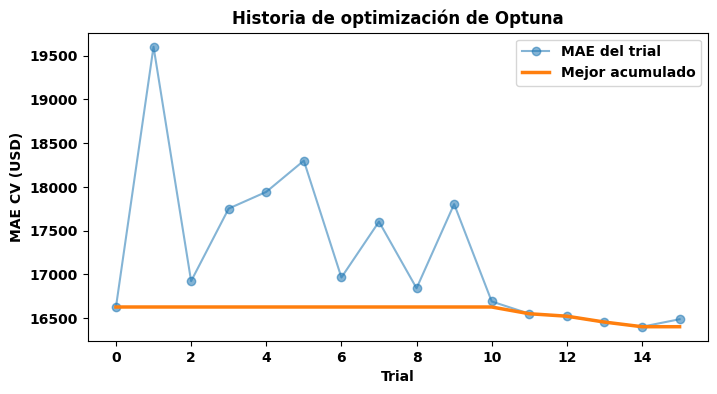

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(optuna_results["number"], optuna_results["value"], "o-", alpha=0.55,
        label="MAE del trial")
ax.plot(optuna_results["number"], optuna_results["value"].cummin(), lw=2.5,
        label="Mejor acumulado")
ax.set(xlabel="Trial", ylabel="MAE CV (USD)", title="Historia de optimización de Optuna")
ax.legend()
plt.show()

## 6. Congelar el procedimiento y abrir test

Seleccionamos el método con menor MAE medio de CV. Esta regla fue definida antes de consultar test. Luego reajustamos su mejor pipeline con todo desarrollo.

In [11]:
optuna_params = {
    "model__n_estimators": study.best_params["n_estimators"],
    "model__learning_rate": study.best_params["learning_rate"],
    "model__max_depth": study.best_params["max_depth"],
    "model__min_samples_leaf": study.best_params["min_samples_leaf"],
}
optuna_best = clone(estimator).set_params(**optuna_params).fit(X_dev, y_dev)
fitted_candidates = {
    "GridSearchCV": grid_search.best_estimator_,
    "RandomizedSearchCV": random_search.best_estimator_,
    "Optuna TPE": optuna_best,
}
selected_method = search_summary.iloc[0]["método"]
final_estimator = fitted_candidates[selected_method]
final_test_mae = mean_absolute_error(y_test, final_estimator.predict(X_test))
pd.DataFrame({
    "procedimiento_congelado": [selected_method],
    "MAE_CV_selección": [search_summary.iloc[0]["mejor_MAE_CV"]],
    "MAE_test_final": [final_test_mae],
})

,procedimiento_congelado,MAE_CV_selección,MAE_test_final
0,GridSearchCV,"16,330.610","16,840.102"


## Interpretación obligatoria

- **Observo:** compare mejor MAE, dispersión y tiempo.
- **Significa:** decida si la diferencia es material frente a la variabilidad.
- **Recomendaría:** declare método, presupuesto y configuración.
- **Vigilaría:** la adaptación repetida a los mismos folds.
- **No puedo concluir:** esta comparación pequeña no demuestra que un buscador sea universalmente superior.

## Reto guiado

Sin ejecutar primero, proponga una segunda búsqueda de solo ocho configuraciones. Debe justificar qué rango estrecha, cuál mantiene amplio y por qué. Compare después el costo y la pérdida de oportunidad.